# Power Consumption Model — Disaster-Relief Mesh Network

Deterministic duty-cycle model for intra-cluster mesh nodes.
Adjust parameters in **Section 2** and re-run.

## 1. Imports

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

COLORS = {
    "LoRa":      "#E07B39",
    "DECT NR+":  "#2E86AB",
    "NB-IoT":    "#A23B72",
    "HaLow":     "#3BB273",
}

## 2. Parameters

### Technology parameters

| Symbol | Description | Unit |
|--------|-------------|------|
| `R_raw` | Physical layer raw data rate | bit/s |
| `eta` | Protocol efficiency η | — |
| `Vcc` | Supply voltage | V |
| `I_tx` | Transmit current | mA |
| `I_rx` | Active receive current | mA |
| `I_idle` | Idle listening current | mA |
| `I_base` | Baseline MCU + peripheral current | mA |

In [102]:
TECHNOLOGIES = {
    "LoRa": {
        "R_raw":  27e3,       # bit/s
        "eta":    0.50,
        "Vcc":    3.3,        # V
        "I_tx":   44.0,       # mA
        "I_rx":   11.0,       # mA
        "I_idle": 1.6,        # mA
        "I_base": 5.0,        # mA
        "viable": True,
        "reason": "Latency too high for voice bursts",
    },
    "DECT NR+": {
        "R_raw":  3456e3,    # bit/s
        "eta":    0.70,
        "Vcc":    3.3,
        "I_tx":   80.0,
        "I_rx":   35.0,
        "I_idle": 5.0,
        "I_base": 5.0,
        "viable": True,
        "reason": "Primary candidate",
    },
    "NB-IoT": {
        "R_raw":  127e3,      # bit/s
        "eta":    0.60,
        "Vcc":    3.8,
        "I_tx":   220.0,
        "I_rx":   46.0,
        "I_idle": 6.0,
        "I_base": 5.0,
        "viable": True,
        "reason": "Requires cellular infrastructure",
    },
    "HaLow": {
        "R_raw":  86700e3,   # bit/s
        "eta":    0.65,
        "Vcc":    3.3,
        "I_tx":   150.0,
        "I_rx":   50.0,
        "I_idle": 10.0,
        "I_base": 5.0,
        "viable": True,
        "reason": "Primary candidate",
    },
}

### Scenario parameters

In [103]:
M          = 32_000    # bits    message size (10 s @ 3.2 kbit/s Codec2)
lambda_m   = 100 / 60    # msg/s   message rate per node (1 per minute)
N          = 16         # —       nodes per cluster
C_bat      = 3000      # mAh     battery capacity
T_lat_max  = 5.0       # s       max acceptable latency budget

## 3. Viability Check

A technology is viable if the worst-case queuing latency
$N \cdot T_{tx} \leq T_{\text{lat,max}}$, where
$T_{tx} = M \;/\; (\eta \cdot R_{\text{raw}})$.

In [104]:
print(f"{'Technology':<14} {'R_max (kbps)':>13} {'T_tx (ms)':>10} "
      f"{'N·T_tx (s)':>11} {'Viable':>8}")
print("-" * 62)

for name, p in TECHNOLOGIES.items():
    R_max = p["eta"] * p["R_raw"]
    T_tx  = M / R_max
    lat   = N * T_tx
    ok    = lat <= T_lat_max
    flag  = "✓" if ok else f"✗  ({p['reason']})"
    print(f"{name:<14} {R_max/1e3:>13.1f} {T_tx*1e3:>10.2f} "
          f"{lat:>11.4f} {flag:>8}")

Technology      R_max (kbps)  T_tx (ms)  N·T_tx (s)   Viable
--------------------------------------------------------------
LoRa                    13.5    2370.37     37.9259 ✗  (Latency too high for voice bursts)
DECT NR+              2419.2      13.23      0.2116        ✓
NB-IoT                  76.2     419.95      6.7192 ✗  (Requires cellular infrastructure)
HaLow                56355.0       0.57      0.0091        ✓


## 4. Deterministic Duty-Cycle Model

Channel load factor:
$$\rho = \frac{N \cdot \lambda_m \cdot M}{\eta \cdot R_{\text{raw}}}$$

Duty cycles:
$$\delta_{Tx} = \frac{\rho}{N}, \qquad
  \delta_{Rx} = \frac{(N-1)\,\rho}{N}, \qquad
  \delta_{\text{idle}} = 1 - \rho$$

Average current:
$$\bar{I} = I_{\text{base}}
          + (1-\rho)\,I_{\text{idle}}
          + \frac{\rho}{N}\,I_{Tx}
          + \frac{(N-1)\rho}{N}\,I_{Rx}$$

Battery lifetime:
$$T_{\text{life}} = \frac{C_{\text{bat}}}{\bar{I}}$$

In [105]:
def power_model(tech, M, lambda_m, N, C_bat):
    R_max  = tech["eta"] * tech["R_raw"]
    T_tx   = M / R_max
    rho    = N * lambda_m * M / R_max

    if rho >= 1.0:
        return None  # channel saturated

    d_tx   = rho / N
    d_rx   = (N - 1) * rho / N
    d_idle = 1.0 - rho

    I_bar  = (tech["I_base"]
              + d_idle * tech["I_idle"]
              + d_tx   * tech["I_tx"]
              + d_rx   * tech["I_rx"])

    T_life = C_bat / I_bar                                  # hours
    eps_b  = 1e6 * tech["Vcc"] * I_bar / (lambda_m * M)    # µJ/bit

    return dict(rho=rho, d_tx=d_tx, d_rx=d_rx, d_idle=d_idle,
                I_bar=I_bar, T_life=T_life, eps_b=eps_b,
                T_tx=T_tx, R_max=R_max)


# Print results
rows = []
for name, tech in TECHNOLOGIES.items():
    r = power_model(tech, M, lambda_m, N, C_bat)
    if r is None:
        rows.append({"Technology": name, "Note": "Channel saturated (ρ≥1)"})
        continue
    rows.append({
        "Technology":    name,
        "ρ":             round(r["rho"],   5),
        "δ_Tx":          round(r["d_tx"],  5),
        "δ_Rx":          round(r["d_rx"],  5),
        "δ_idle":        round(r["d_idle"],5),
        "Ī (mA)":        round(r["I_bar"], 3),
        "T_life (h)":    round(r["T_life"],2),
        "ε_b (µJ/bit)":  round(r["eps_b"],2),
    })

df = pd.DataFrame(rows).set_index("Technology")
display(df)

,Note,ρ,δ_Tx,δ_Rx,δ_idle,Ī (mA),T_life (h),ε_b (µJ/bit)
Technology,,,,,,,,
LoRa,Channel saturated (ρ≥1),NaN,NaN,NaN,NaN,NaN,NaN,NaN
DECT NR+,NaN,0.35273,0.02205,0.33069,0.64727,21.574,139.06,1334.90
NB-IoT,Channel saturated (ρ≥1),NaN,NaN,NaN,NaN,NaN,NaN,NaN
HaLow,NaN,0.01514,0.00095,0.01420,0.98486,15.700,191.08,971.46


## 5. Sensitivity Sweeps

Each plot sweeps one parameter while holding the others at the
baseline values defined in Section 2.

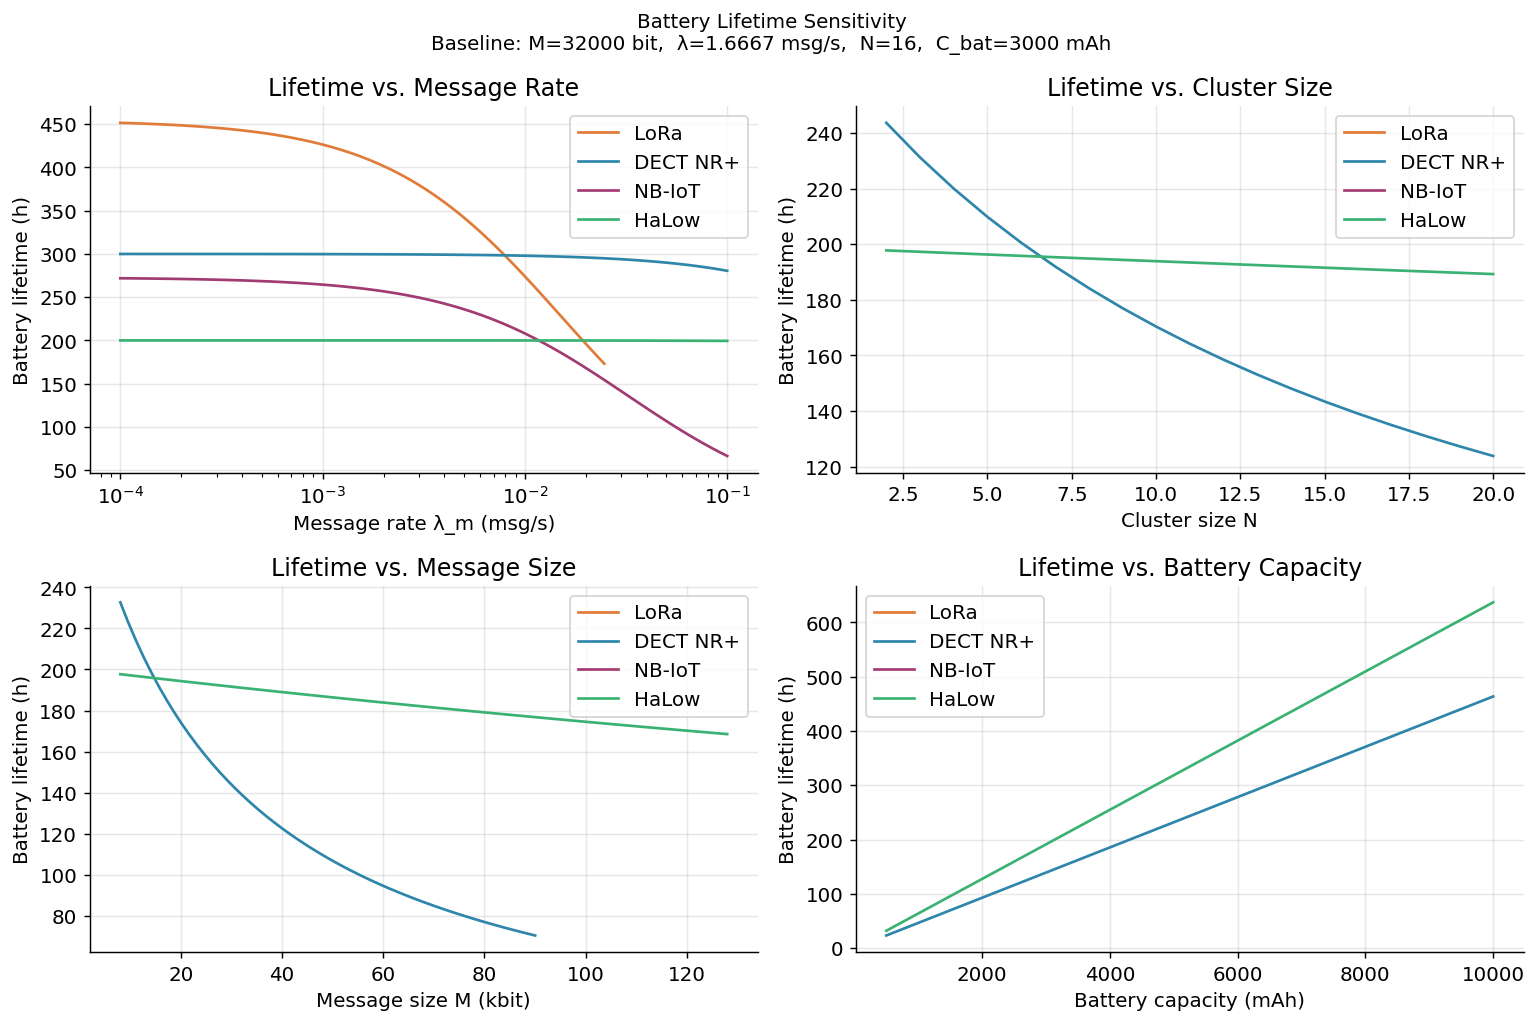

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    f"Battery Lifetime Sensitivity\n"
    f"Baseline: M={M} bit,  λ={lambda_m:.4f} msg/s,  "
    f"N={N},  C_bat={C_bat} mAh",
    fontsize=11
)

viable = [n for n, t in TECHNOLOGIES.items() if t["viable"]]

def sweep(param, values, base):
    """Return {tech: [T_life, ...]} sweeping one parameter."""
    out = {n: [] for n in viable}
    for v in values:
        p = {**base, param: v}
        for name in viable:
            r = power_model(TECHNOLOGIES[name],
                            p["M"], p["lambda_m"], p["N"], p["C_bat"])
            out[name].append(r["T_life"] if r else np.nan)
    return out

base = dict(M=M, lambda_m=lambda_m, N=N, C_bat=C_bat)

sweeps = [
    ("lambda_m", np.logspace(-4, -1, 80),  axes[0,0],
     "Message rate λ_m (msg/s)", "log",   "Lifetime vs. Message Rate"),
    ("N",        np.arange(2, 21),          axes[0,1],
     "Cluster size N",           "linear", "Lifetime vs. Cluster Size"),
    ("M",        np.linspace(8e3,128e3,80), axes[1,0],
     "Message size M (bit)",     "linear", "Lifetime vs. Message Size"),
    ("C_bat",    np.linspace(500,10000,80), axes[1,1],
     "Battery capacity (mAh)",   "linear", "Lifetime vs. Battery Capacity"),
]

for param, vals, ax, xlabel, xscale, title in sweeps:
    res = sweep(param, vals, base)
    x   = vals / 1e3 if param == "M" else vals   # kbit for M axis
    for name in viable:
        ax.plot(x, res[name], color=COLORS[name], label=name)
    ax.set_xlabel("Message size M (kbit)" if param == "M" else xlabel)
    ax.set_ylabel("Battery lifetime (h)")
    ax.set_title(title)
    ax.set_xscale(xscale)
    ax.legend()

plt.tight_layout()
plt.savefig("fig_sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()

## 6. Duty-Cycle Breakdown and Lifetime Comparison

TypeError: 'NoneType' object is not subscriptable

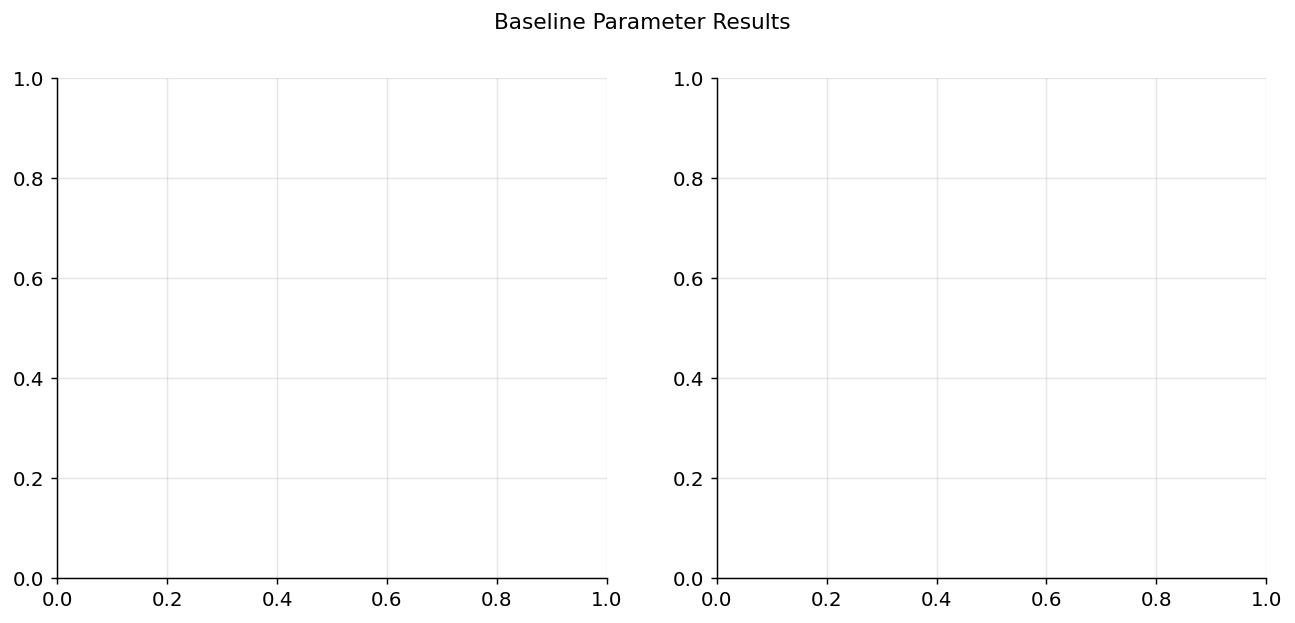

In [107]:
fig2, (ax_dc, ax_life) = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("Baseline Parameter Results", fontsize=12)

# Duty-cycle grouped bar chart
states     = ["δ_Tx", "δ_Rx", "δ_idle"]
bar_width  = 0.30
x          = np.arange(len(states))

for i, name in enumerate(viable):
    r      = power_model(TECHNOLOGIES[name], M, lambda_m, N, C_bat)
    vals   = [r["d_tx"], r["d_rx"], r["d_idle"]]
    offset = (i - len(viable)/2 + 0.5) * bar_width
    ax_dc.bar(x + offset, vals, bar_width,
              color=COLORS[name], label=name, alpha=0.85)

ax_dc.set_xticks(x)
ax_dc.set_xticklabels(states)
ax_dc.set_ylabel("Duty-cycle fraction")
ax_dc.set_title("Duty-Cycle Breakdown")
ax_dc.legend()

# Battery lifetime bar chart
lives = [power_model(TECHNOLOGIES[n], M, lambda_m, N, C_bat)["T_life"]
         for n in viable]
bars  = ax_life.bar(viable, lives,
                    color=[COLORS[n] for n in viable], alpha=0.85)
ax_life.bar_label(bars, fmt="%.1f h", padding=4)
ax_life.set_ylabel("Battery lifetime (h)")
ax_life.set_title("Battery Lifetime at Baseline")

plt.tight_layout()
plt.savefig("fig_breakdown.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Energy per Bit vs. Message Rate

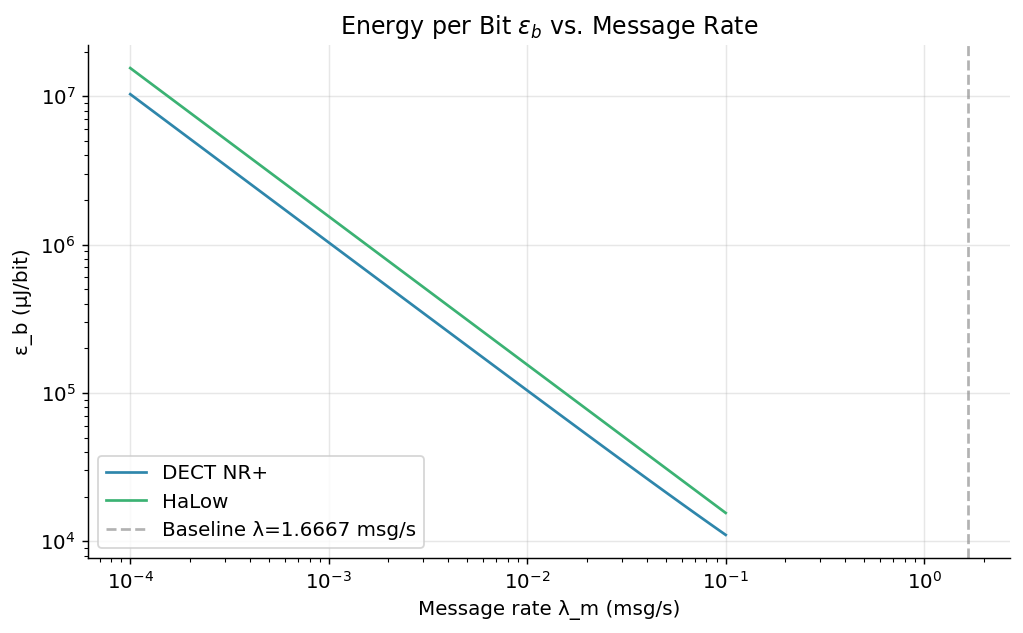

In [ ]:
fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.set_title("Energy per Bit $\\varepsilon_b$ vs. Message Rate")

lambdas = np.logspace(-4, -1, 80)

for name in viable:
    tech = TECHNOLOGIES[name]
    eps  = []
    for lm in lambdas:
        r = power_model(tech, M, lm, N, C_bat)
        eps.append(r["eps_b"] if r else np.nan)
    ax3.plot(lambdas, eps, color=COLORS[name], label=name)

ax3.axvline(lambda_m, color="gray", linestyle="--",
            alpha=0.6, label=f"Baseline λ={lambda_m:.4f} msg/s")
ax3.set_xlabel("Message rate λ_m (msg/s)")
ax3.set_ylabel("ε_b (µJ/bit)")
ax3.set_xscale("log")
ax3.set_yscale("log")
ax3.legend()
plt.tight_layout()
plt.savefig("fig_epb.png", bbox_inches="tight", dpi=150)
plt.show()